In [1]:
%matplotlib inline
from matplotlib import style
style.use('fivethirtyeight')
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import datetime as dt

# Reflect Tables into SQLAlchemy ORM

In [6]:
# Python SQL toolkit and Object Relational Mapper
import sqlalchemy
from sqlalchemy.ext.automap import AutomapBase
from sqlalchemy.orm import Session
from sqlalchemy import create_engine, func

In [7]:
# create engine to hawaii.sqlite
engine = create_engine("sqlite:///Resources/hawaii.sqlite")

In [9]:
# reflect an existing database into a new model
Base = automap_base()
# reflect the tables
Base.prepare(engine)


In [10]:
# View all of the classes that automap found
Base.classes.keys()

['station', 'measurement']

In [11]:
# Save references to each table
Measurement = Base.classes.measurement
Station = Base.classes.station

In [12]:
# Create our session (link) from Python to the DB
session = Session(engine)

# Exploratory Precipitation Analysis

In [13]:
# Find the most recent date in the data set.
most_recent_date = session.query(func.max(Measurement.date)).scalar()
most_recent_date = dt.datetime.strptime(most_recent_date, '%Y-%m-%d')

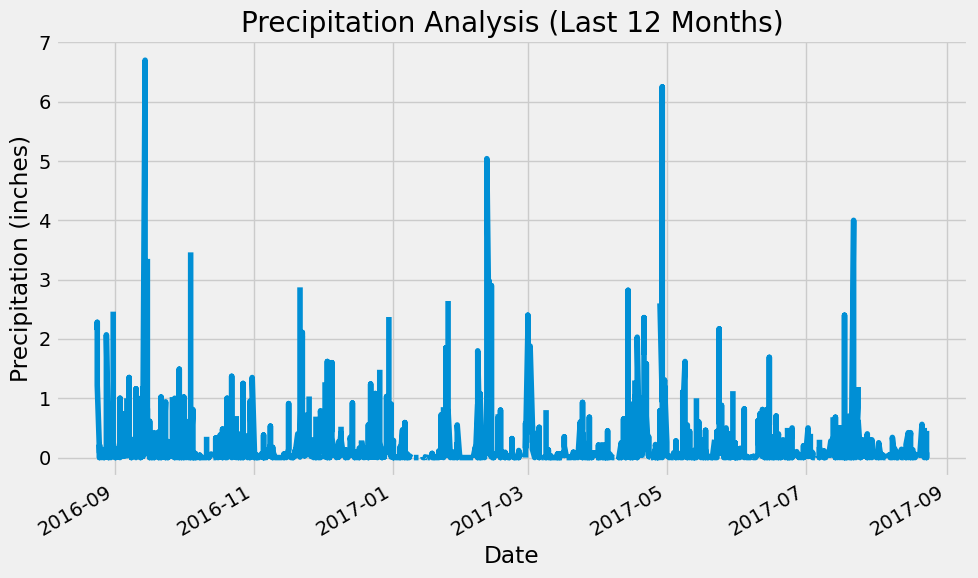

In [14]:
# Design a query to retrieve the last 12 months of precipitation data and plot the results. 
# Starting from the most recent data point in the database. 
last_12_months = session.query(Measurement.date, Measurement.prcp).filter(Measurement.date >= '2017-08-23').all()

# Calculate the date one year from the last date in data set
prev_year = most_recent_date - dt.timedelta(days=365)

# Perform a query to retrieve the date and precipitation scores for the last year
precip_data = session.query(Measurement.date, Measurement.prcp).\
    filter(Measurement.date >= prev_year).all()
# Load the query results into a DataFrame and set the index to the date column
precip_df = pd.DataFrame(precip_data, columns=['date', 'precipitation'])
precip_df['date'] = pd.to_datetime(precip_df['date'])
precip_df.set_index('date', inplace=True)


# Sort the DataFrame values by date
precip_df = precip_df.sort_index()

# Use Pandas Plotting with Matplotlib to plot the data
precip_df.plot(figsize=(10, 6), legend=False)
plt.title("Precipitation Analysis (Last 12 Months)")
plt.xlabel("Date")
plt.ylabel("Precipitation (inches)")
plt.tight_layout()
plt.show()

In [15]:
# Use Pandas to calculate the summary statistics for the precipitation data
precip_df.describe()

,precipitation
count,2015.000000
mean,0.176462
std,0.460288
min,0.000000
25%,0.000000
50%,0.020000
75%,0.130000
max,6.700000


# Exploratory Station Analysis

In [16]:
# Design a query to calculate the total number of stations in the dataset
station_count = session.query(func.count(Station.station)).scalar()
print(f"Total number of stations: {station_count}")

Total number of stations: 9


In [17]:
# Design a query to find the most active stations (i.e. which stations have the most rows?)
# List the stations and their counts in descending order.
active_stations = session.query(Measurement.station, func.count(Measurement.station)).\
    group_by(Measurement.station).\
    order_by(func.count(Measurement.station).desc()).all()
most_active_station = active_stations[0][0]
print(f"Most active station: {most_active_station}")

Most active station: USC00519281


In [18]:
# Using the most active station id from the previous query, calculate the lowest, highest, and average temperature.
station_temps = session.query(
    func.min(Measurement.tobs),
    func.max(Measurement.tobs),
    func.avg(Measurement.tobs)
).filter(Measurement.station == most_active_station).all()
print(f"Temperature stats for {most_active_station}: {station_temps}")

Temperature stats for USC00519281: [(54.0, 85.0, 71.66378066378067)]


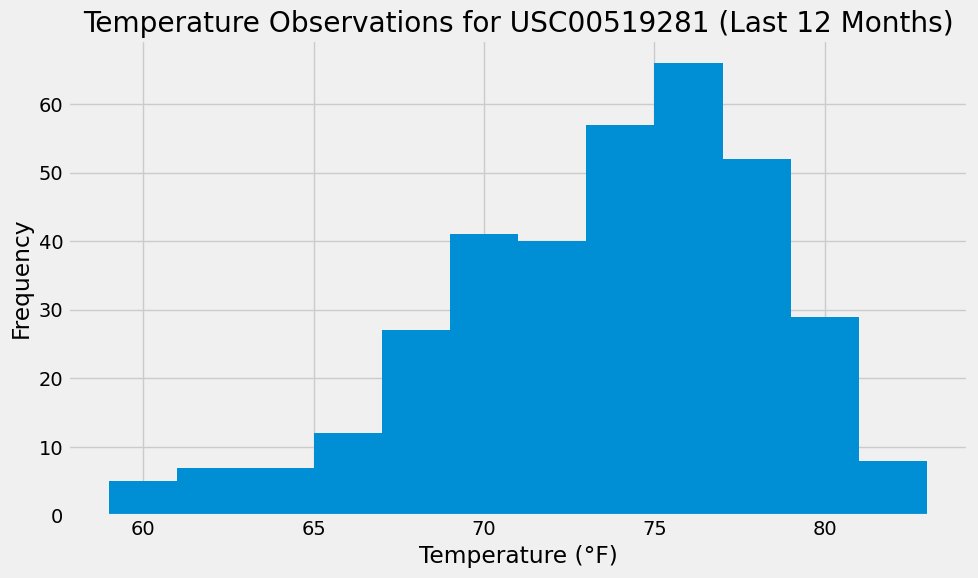

In [20]:
# Using the most active station id
# Query the last 12 months of temperature observation data for this station and plot the results as a histogram
station_tobs = session.query(Measurement.date, Measurement.tobs).\
    filter(Measurement.station == most_active_station).\
    filter(Measurement.date >= prev_year).all()

# Load the query results into a DataFrame
station_tobs_df = pd.DataFrame(station_tobs, columns=['date', 'temperature'])

# Plot a histogram with bins=12
station_tobs_df['temperature'].plot.hist(bins=12, figsize=(10, 6))
plt.title(f"Temperature Observations for {most_active_station} (Last 12 Months)")
plt.xlabel("Temperature (°F)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Close Session

In [21]:
# Close Session
session.close()